# RetailPulse – Data Profiling

## Project
RetailPulse – Retail Customer Analytics & Demand Forecasting Platform

## Objective
Perform an initial data-quality and business-oriented assessment
of the Online Retail transaction dataset.

## Profiling Areas
- Dataset structure
- Data types
- Missing values
- Duplicate records
- Unique values
- Transaction patterns
- Cancellation records
- Negative quantities
- Zero/negative prices
- Date range
- Product information
- Customer information
- Revenue distribution

## Important Principle
No records will be deleted during profiling.
Cleaning decisions will be made after investigating the data.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


# Load Dataset

In [2]:
df_2009_2010 = pd.read_excel("online_retail_II.xlsx",sheet_name='Year 2009-2010')

In [3]:
df_2010_2011 = pd.read_excel("online_retail_II.xlsx",sheet_name='Year 2010-2011')

In [4]:
df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)


# Basic inspection of data

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [7]:
df.shape

(1067371, 8)

In [8]:
df.sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
437225,531210,85232B,SET OF 3 BABUSHKA STACKING TINS,1,2010-11-05 16:07:00,4.95,13263.0,United Kingdom
281700,516839,20727,LUNCH BAG BLACK SKULL.,10,2010-07-23 11:17:00,1.65,12647.0,Germany
164925,504938,22359,"GLASS JAR, KINGS CHOICE SOAP",4,2010-04-19 11:36:00,2.95,15321.0,United Kingdom
833996,564023,20727,LUNCH BAG BLACK SKULL.,10,2011-08-22 12:16:00,1.65,17562.0,United Kingdom
189475,507380,22553,PLASTERS IN TIN SKULLS,1,2010-05-09 11:40:00,1.65,13838.0,United Kingdom
34226,492244,21344,MOROCCAN BEATEN METAL DISH,2,2009-12-16 09:37:00,9.95,17646.0,United Kingdom
1004217,577106,20728,LUNCH BAG CARS BLUE,1,2011-11-17 17:18:00,1.65,14456.0,United Kingdom
49709,494011,16254,TRANSPARENT ACRYLIC TAPE DISPENSER,1,2010-01-11 09:30:00,1.70,NaN,United Kingdom
255826,514087,22713,CARD I LOVE LONDON,288,2010-06-30 12:04:00,0.36,16684.0,United Kingdom
754096,556936,22185,SLATE TILE NATURAL HANGING,6,2011-06-15 16:04:00,1.65,NaN,United Kingdom


In [9]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [11]:
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [12]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [13]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

# Data Quality Report

In [5]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Percentage": (
        df.isnull().mean().values * 100
    ).round(2),
    "Unique_Count": df.nunique(dropna=True).values
})

quality_report

,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Count
0,Invoice,object,0,0.00,53628
1,StockCode,object,0,0.00,5305
2,Description,object,4382,0.41,5698
3,Quantity,int64,0,0.00,1057
4,InvoiceDate,datetime64[ns],0,0.00,47635
5,Price,float64,0,0.00,2807
6,Customer ID,float64,243007,22.77,5942
7,Country,object,0,0.00,43


In [6]:
quality_report.sort_values(
    by="Missing_Count",
    ascending=False
).reset_index(drop=True)

,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Count
0,Customer ID,float64,243007,22.77,5942
1,Description,object,4382,0.41,5698
2,StockCode,object,0,0.00,5305
3,Invoice,object,0,0.00,53628
4,Quantity,int64,0,0.00,1057
5,InvoiceDate,datetime64[ns],0,0.00,47635
6,Price,float64,0,0.00,2807
7,Country,object,0,0.00,43


### Missing Value Visualization

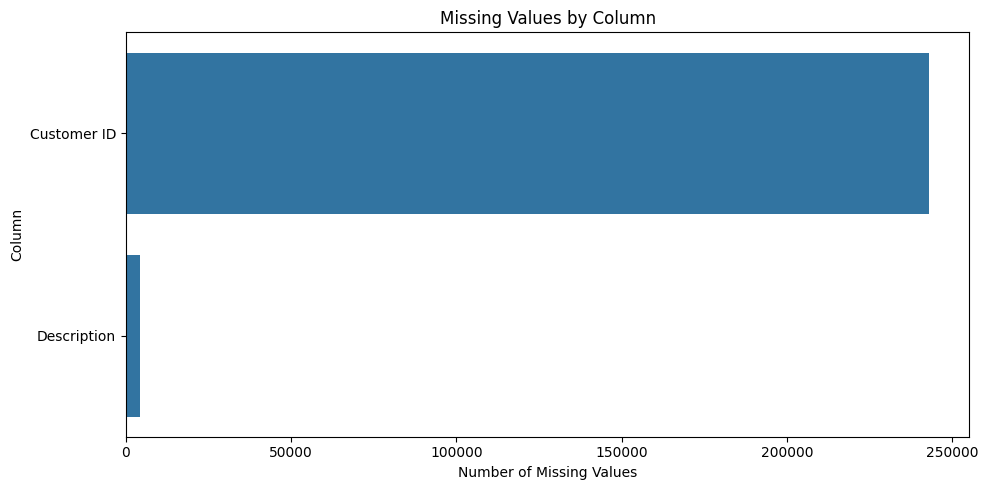

In [7]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

In [8]:
missing_percentage = (
    df.isnull()
  .mean()
  .sort_values(ascending=False) * 100
)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

missing_percentage

Customer ID    22.766873
Description     0.410541
dtype: float64

In [9]:
duplicates = df[
    df.duplicated(keep=False)
].sort_values(
    by=df.columns.tolist()
)

duplicates.head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom


### Customer ID investigation

In [11]:
customer_missing = df["Customer ID"].isna().sum()

print("Missing CustomerID:", customer_missing)

print(
    f"Missing CustomerID percentage: "
    f"{customer_missing / len(df) * 100:.2f}%"
)

Missing CustomerID: 243007
Missing CustomerID percentage: 22.77%


In [13]:
missing_customer_df = df[
    df["Customer ID"].isna()
]

missing_customer_df.head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [15]:
missing_customer_df[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Country"
    ]
].head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,United Kingdom


### Description Investigation

In [16]:
description_missing = df["Description"].isna().sum()

print("Missing Description:", description_missing)

print(
    f"Missing Description percentage: "
    f"{description_missing / len(df) * 100:.2f}%"
)

Missing Description: 4382
Missing Description percentage: 0.41%


In [17]:
missing_description_df = df[
    df["Description"].isna()
]

missing_description_df.head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom


In [19]:
missing_description_df[
    [
        "StockCode",
        "Invoice",
        "Quantity",
        "Price",
        "Customer ID",
        "Country"
    ]
].head(50)

,StockCode,Invoice,Quantity,Price,Customer ID,Country
470,21646,489521,-50,0.0,NaN,United Kingdom
3114,20683,489655,-44,0.0,NaN,United Kingdom
3161,21350,489659,230,0.0,NaN,United Kingdom
3731,84292,489781,17,0.0,NaN,United Kingdom
4296,18010,489806,-770,0.0,NaN,United Kingdom
4566,85049G,489821,-240,0.0,NaN,United Kingdom
6378,35751C,489882,12,0.0,NaN,United Kingdom
6555,79323G,489898,954,0.0,NaN,United Kingdom
6576,21098,489901,-200,0.0,NaN,United Kingdom
6581,21166,489903,48,0.0,NaN,United Kingdom


### Unique StockCode

In [20]:
print(
    "Unique StockCodes:",
    df["StockCode"].nunique()
)

Unique StockCodes: 5305


In [21]:
print(
    "Unique descriptions:",
    df["Description"].nunique()
)

Unique descriptions: 5698


In [22]:
df["Description"].value_counts(
    dropna=True
).head(20)

Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2529
JUMBO STORAGE BAG SUKI                2434
HEART OF WICKER SMALL                 2319
JUMBO SHOPPER VINTAGE RED PAISLEY     2297
60 TEATIME FAIRY CAKE CASES           2271
PAPER CHAIN KIT 50'S CHRISTMAS        2215
LUNCH BAG SPACEBOY DESIGN             2206
REX CASH+CARRY JUMBO SHOPPER          2199
HOME BUILDING BLOCK WORD              2192
WOODEN FRAME ANTIQUE WHITE            2189
LUNCH BAG CARS BLUE                   2184
NATURAL SLATE HEART CHALKBOARD        2151
BAKING SET 9 PIECE RETROSPOT          2150
POSTAGE                               2115
Name: count, dtype: int64

### Country Analysis

In [23]:
print(
    "Number of countries:",
    df["Country"].nunique()
)

Number of countries: 43


In [24]:
df["Country"].value_counts().head(20)

Country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Finland              1049
Austria               938
Denmark               817
Unspecified           756
Greece                663
Name: count, dtype: int64

### Invoice Analysis

In [25]:
print(df["Invoice"].dtype)

object


In [27]:
invoice_text = df["Invoice"].astype(str)

## Cancellation Records

In [28]:
cancelled_mask = invoice_text.str.startswith("C")

In [29]:
cancelled_count = cancelled_mask.sum()

print("Cancellation records:", cancelled_count)

print(
    f"Cancellation percentage: "
    f"{cancelled_count / len(df) * 100:.2f}%"
)

Cancellation records: 19494
Cancellation percentage: 1.83%


In [30]:
cancelled_df = df[
    cancelled_mask
]

cancelled_df.head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [31]:
cancelled_df[
    "Description"
].value_counts(
    dropna=False
).head(30)

Description
Manual                                 538
REGENCY CAKESTAND 3 TIER               347
POSTAGE                                229
BAKING SET 9 PIECE RETROSPOT           211
STRAWBERRY CERAMIC TRINKET BOX         184
Discount                               172
WHITE HANGING HEART T-LIGHT HOLDER     135
WHITE CHERRY LIGHTS                    121
RED RETROSPOT CAKE STAND               111
SAMPLES                                101
JAM MAKING SET WITH JARS                90
WOOD 2 DRAWER CABINET WHITE FINISH      89
PINK CHERRY LIGHTS                      86
SET OF 3 CAKE TINS PANTRY DESIGN        74
JUMBO BAG RED RETROSPOT                 74
RED RETROSPOT TRADITIONAL TEAPOT        74
SWEETHEART CERAMIC TRINKET BOX          73
CERAMIC CAKE STAND + HANGING CAKES      72
SMALL GLASS HEART TRINKET POT           71
BAKING SET SPACEBOY DESIGN              68
SILVER HANGING T-LIGHT HOLDER           68
LARGE CAKE STAND  HANGING STRAWBERY     65
GUMBALL COAT RACK                       65

### Quantity analysis

In [32]:
print(
    "Positive quantity:",
    (df["Quantity"] > 0).sum()
)

print(
    "Zero quantity:",
    (df["Quantity"] == 0).sum()
)

print(
    "Negative quantity:",
    (df["Quantity"] < 0).sum()
)

Positive quantity: 1044421
Zero quantity: 0
Negative quantity: 22950


### Negative Quality Percentage

In [33]:
negative_quantity_count = (
    df["Quantity"] < 0
).sum()

print(
    f"Negative quantity percentage: "
    f"{negative_quantity_count / len(df) * 100:.2f}%"
)

Negative quantity percentage: 2.15%


In [34]:
negative_quantity_df = df[
    df["Quantity"] < 0
]

negative_quantity_df.head(50)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


### Compare negative quantities with cancellations

In [36]:
pd.crosstab(
    negative_quantity_df["Invoice"]
        .astype(str)
        .str.startswith("C"),
    columns="Count"
)

col_0,Count
Invoice,
False,3457
True,19493


### Price analysis

In [37]:
print(
    "Zero Price:",
    (df["Price"] == 0).sum()
)

print(
    "Negative Price:",
    (df["Price"] < 0).sum()
)

Zero Price: 6202
Negative Price: 5


In [39]:
zero_negative_price = df[
    df["Price"] <= 0
]

zero_negative_price.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [40]:
print(
    "InvoiceDate data type:",
    df["InvoiceDate"].dtype
)

InvoiceDate data type: datetime64[ns]


### Convert date for profiling

In [41]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

In [42]:
print(
    "Invalid InvoiceDate values:",
    df["InvoiceDate"].isna().sum()
)

Invalid InvoiceDate values: 0


### Data Range

In [43]:
print(
    "Minimum transaction date:",
    df["InvoiceDate"].min()
)

print(
    "Maximum transaction date:",
    df["InvoiceDate"].max()
)

Minimum transaction date: 2009-12-01 07:45:00
Maximum transaction date: 2011-12-09 12:50:00


### Create Revenue

In [44]:
df["Revenue"] = (
    df["Quantity"] *
    df["Price"]
)

In [45]:
df["Revenue"].describe()

count    1.067371e+06
mean     1.806987e+01
std      2.924202e+02
min     -1.684696e+05
25%      3.750000e+00
50%      9.900000e+00
75%      1.770000e+01
max      1.684696e+05
Name: Revenue, dtype: float64

In [46]:
print(
    f"Total transaction value: "
    f"{df['Revenue'].sum():,.2f}"
)

print(
    f"Average transaction-line value: "
    f"{df['Revenue'].mean():,.2f}"
)

print(
    f"Minimum transaction-line value: "
    f"{df['Revenue'].min():,.2f}"
)

print(
    f"Maximum transaction-line value: "
    f"{df['Revenue'].max():,.2f}"
)

Total transaction value: 19,287,250.57
Average transaction-line value: 18.07
Minimum transaction-line value: -168,469.60
Maximum transaction-line value: 168,469.60


### Revenue Distribution

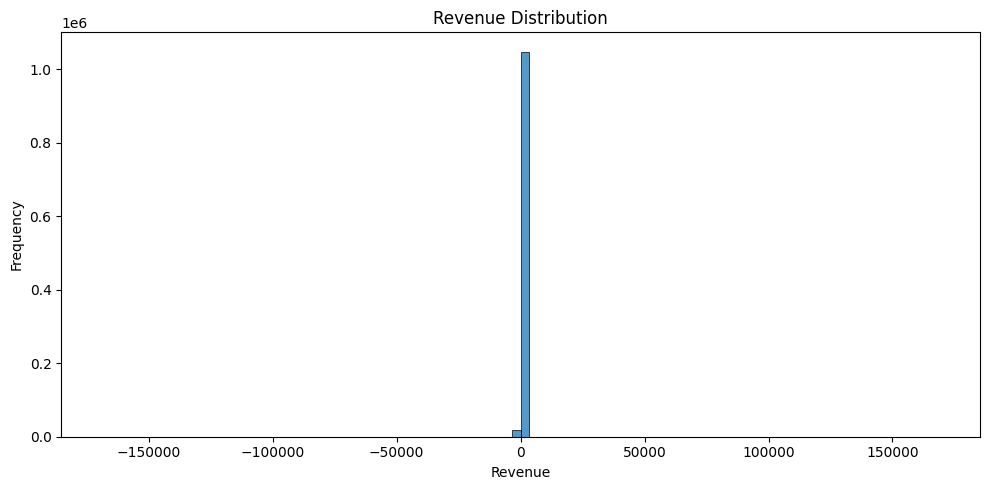

In [47]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Revenue"],
    bins=100
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Quantity Distribution

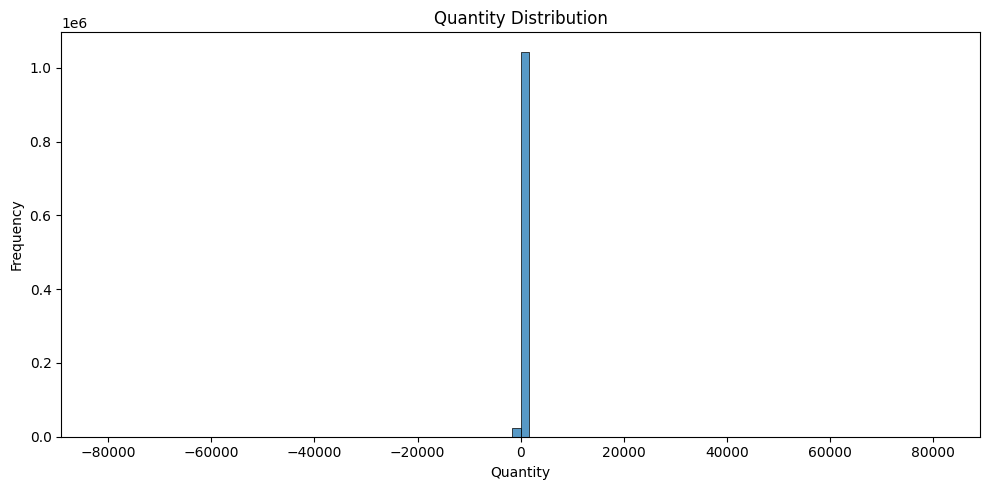

In [48]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Quantity"],
    bins=100
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Price Distribution

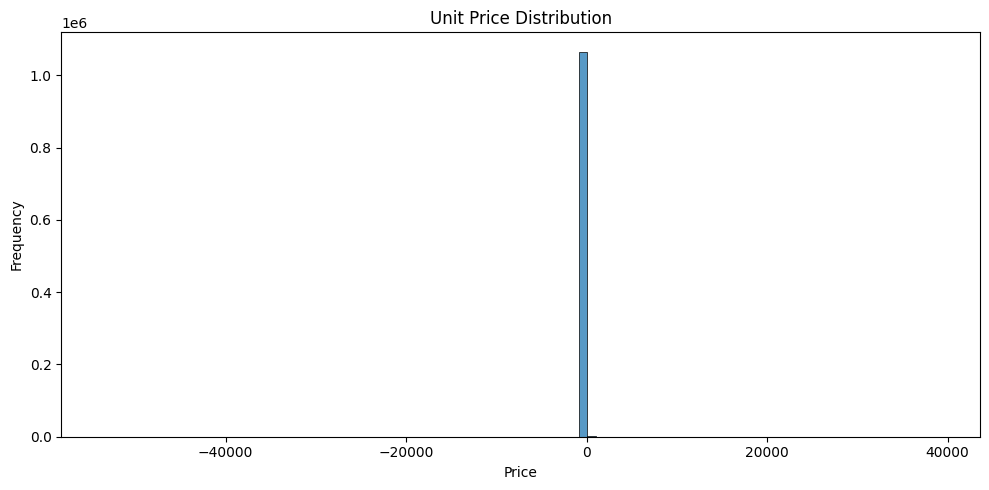

In [50]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Price"],
    bins=100
)

plt.title("Unit Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Country transaction distribution

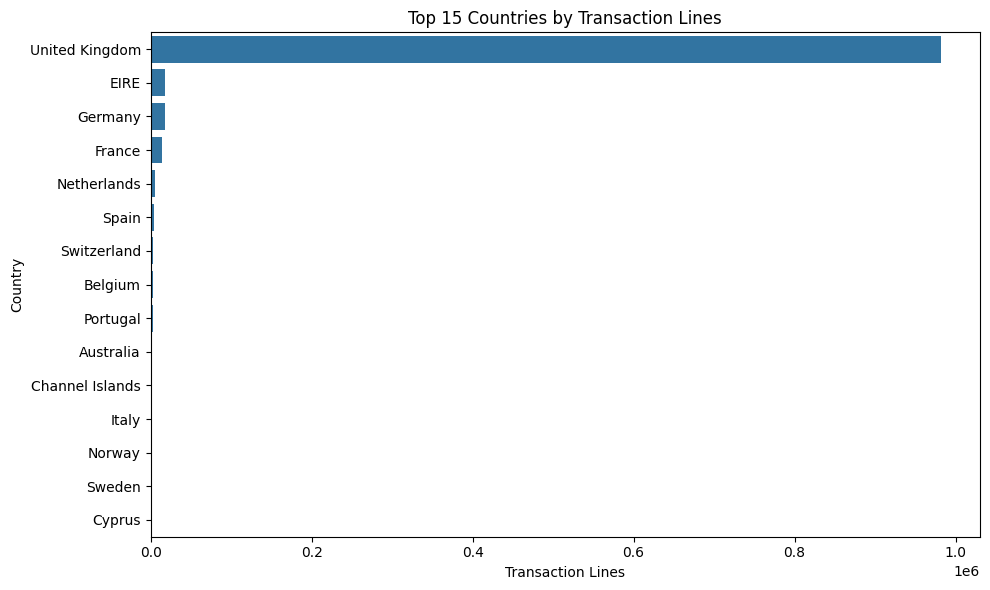

In [51]:
country_transactions = (
    df["Country"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_transactions.values,
    y=country_transactions.index
)

plt.title("Top 15 Countries by Transaction Lines")
plt.xlabel("Transaction Lines")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Monthly Transaction Value

In [52]:
monthly_transactions = (
    df.set_index("InvoiceDate")
      .resample("ME")
      .size()
)

monthly_transactions

InvoiceDate
2009-12-31    45228
2010-01-31    31555
2010-02-28    29388
2010-03-31    41511
2010-04-30    34057
2010-05-31    35323
2010-06-30    39983
2010-07-31    33383
2010-08-31    33306
2010-09-30    42091
2010-10-31    59098
2010-11-30    78015
2010-12-31    65004
2011-01-31    35147
2011-02-28    27707
2011-03-31    36748
2011-04-30    29916
2011-05-31    37030
2011-06-30    36874
2011-07-31    39518
2011-08-31    35284
2011-09-30    50226
2011-10-31    60742
2011-11-30    84711
2011-12-31    25526
Freq: ME, dtype: int64

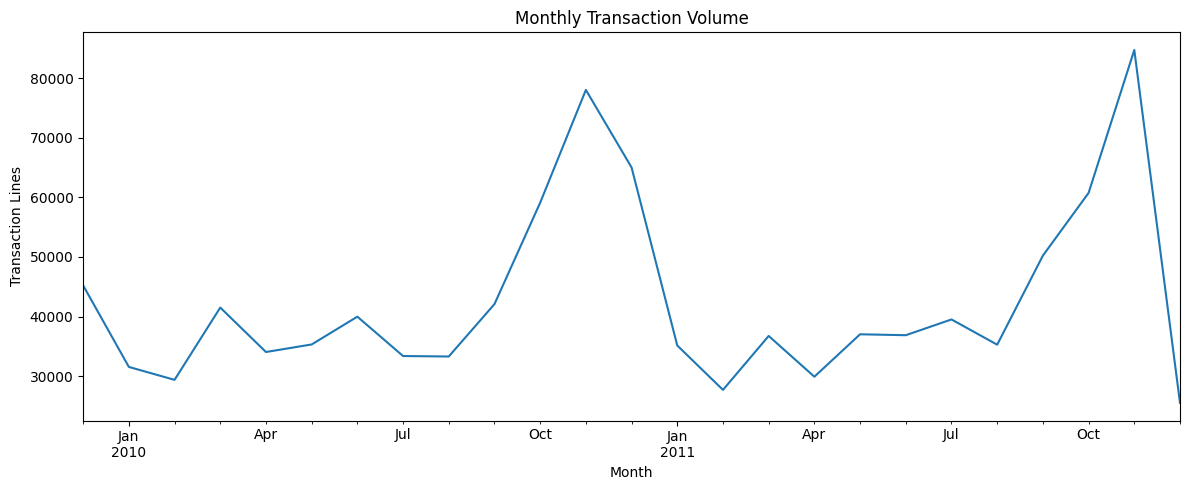

In [53]:
plt.figure(figsize=(12, 5))

monthly_transactions.plot()

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Transaction Lines")

plt.tight_layout()
plt.show()

### Monthly Revenue

In [54]:
monthly_revenue = (
    df.set_index("InvoiceDate")["Revenue"]
      .resample("ME")
      .sum()
)

monthly_revenue

InvoiceDate
2009-12-31     799847.110
2010-01-31     624032.892
2010-02-28     533091.426
2010-03-31     765848.761
2010-04-30     590580.432
2010-05-31     615322.830
2010-06-30     679786.610
2010-07-31     575236.360
2010-08-31     656776.340
2010-09-30     853650.431
2010-10-31    1045168.350
2010-11-30    1422654.642
2010-12-31    1126445.470
2011-01-31     560000.260
2011-02-28     498062.650
2011-03-31     683267.080
2011-04-30     493207.121
2011-05-31     723333.510
2011-06-30     691123.120
2011-07-31     681300.111
2011-08-31     682680.510
2011-09-30    1019687.622
2011-10-31    1070704.670
2011-11-30    1461756.250
2011-12-31     433686.010
Freq: ME, Name: Revenue, dtype: float64

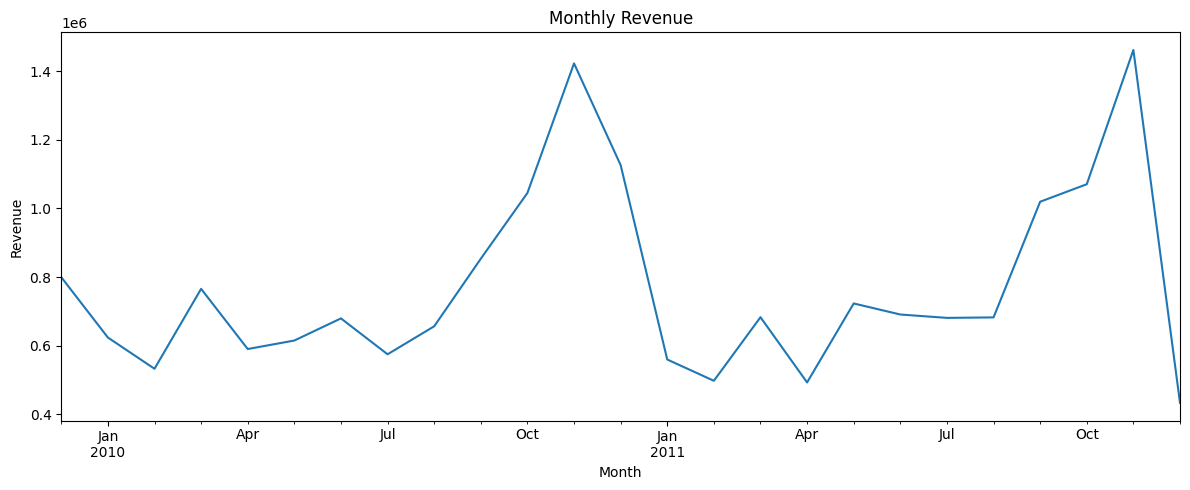

In [55]:
plt.figure(figsize=(12, 5))

monthly_revenue.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### Customer Coverage

In [57]:
total_records = len(df)

identified_customer_records = (
    df["Customer ID"].notna().sum()
)

anonymous_records = (
    df["Customer ID"].isna().sum()
)

print(
    "Records with CustomerID:",
    identified_customer_records
)

print(
    "Records without CustomerID:",
    anonymous_records
)

print(
    f"Customer identification rate: "
    f"{identified_customer_records / total_records * 100:.2f}%"
)

Records with CustomerID: 824364
Records without CustomerID: 243007
Customer identification rate: 77.23%


In [59]:
unique_customers = df["Customer ID"].nunique()

print(
    "Unique identifiable customers:",
    unique_customers
)

Unique identifiable customers: 5942


In [61]:
unique_invoices = df["Invoice"].nunique()

print(
    "Unique invoices:",
    unique_invoices
)

Unique invoices: 53628


In [63]:
cancelled_invoices = (
    df.loc[cancelled_mask, "Invoice"]
      .nunique()
)

print(
    "Unique cancelled invoices:",
    cancelled_invoices
)

Unique cancelled invoices: 8292


# Data profiling summary

In [65]:
profiling_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Duplicate Records",
        "Missing CustomerID",
        "Missing Description",
        "Unique Customers",
        "Unique Invoices",
        "Unique Products",
        "Unique Countries",
        "Cancellation Records",
        "Negative Quantity Records",
        "Zero Quantity Records",
        "Zero Price Records",
        "Negative Price Records",
        "Invalid Dates"
    ],
    
    "Value": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df["Customer ID"].isna().sum(),
        df["Description"].isna().sum(),
        df["Customer ID"].nunique(),
        df["Invoice"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique(),
        cancelled_mask.sum(),
        (df["Quantity"] < 0).sum(),
        (df["Quantity"] == 0).sum(),
        (df["Price"] == 0).sum(),
        (df["Price"] < 0).sum(),
        df["InvoiceDate"].isna().sum()
    ]
})

profiling_summary

,Metric,Value
0,Total Records,1067371
1,Total Columns,9
2,Duplicate Records,34335
3,Missing CustomerID,243007
4,Missing Description,4382
5,Unique Customers,5942
6,Unique Invoices,53628
7,Unique Products,5305
8,Unique Countries,43
9,Cancellation Records,19494


# Final notebook conclusion

# Profiling Conclusion

The initial profiling identified the following areas requiring further investigation:

1. Missing CustomerID values
2. Missing Description values
3. Duplicate transaction records
4. Cancellation invoices
5. Negative quantities
6. Zero/negative UnitPrice values
7. Date validity
8. Product/StockCode anomalies
9. Anonymous transactions
10. Revenue anomalies

No records were deleted during profiling.

The next stage is to investigate each issue and establish
business-driven data-cleaning rules.